# SAM3 Image Detection

This notebook demonstrates how to use FilterSAM3Detector to detect objects in an image.


In [17]:
import cv2
import numpy as np
from pathlib import Path
from openfilter.filter_runtime.filter import Frame
from filter_sam3_detector.filter import FilterSAM3Detector
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


## Configuration

Configure the image path and detection prompt:


In [31]:
# Configuration
image_path = Path("imgs_demo/salad1.png")  # Change to your image path
confidence_threshold = 0.2  # Minimum confidence threshold for SAM3 detector
min_score_filter = 0.7  # Minimum score to keep in final results (filters out low-confidence detections)

# Define objects to detect (each will be processed separately to get labeled bounding boxes)
objects_to_detect = ["avocado", "tomato"]  # List of objects to detect

# Note: Processing each object separately ensures we get labeled bounding boxes
# for each type (avocado vs tomato)

print(min_score_filter, confidence_threshold)

0.7 0.2


## Load Image


Image loaded: salad1.png
Dimensions: 3784x1936


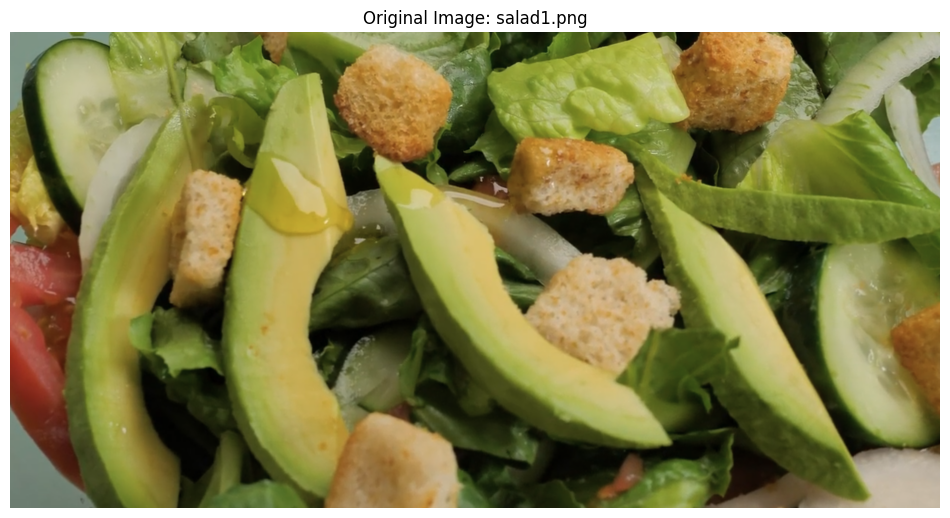

In [32]:
# Load image
img_bgr = cv2.imread(str(image_path))
if img_bgr is None:
    raise ValueError(f"Could not load image: {image_path}")

# Convert BGR to RGB for visualization
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"Image loaded: {image_path.name}")
print(f"Dimensions: {img_bgr.shape[1]}x{img_bgr.shape[0]}")

# Visualize original image
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f"Original Image: {image_path.name}")
plt.show()


## Initialize SAM3 Detector

We'll process each object type separately to get labeled bounding boxes.


In [33]:
# Initialize detector (we'll change the prompt for each object)
detector = FilterSAM3Detector({
    "text_prompt": objects_to_detect[0],  # Will be updated for each object
    "confidence_threshold": confidence_threshold,
    "device": "cuda",  # or "cpu" if no GPU
    "visualize": False,
    "output_label": "detections",
})

detector.setup(detector.config)
print("SAM3 Detector initialized successfully!")


2025-12-19 04:55:30.890 1606063 INFO     [Filter] Raw subject data export is DISABLED (set OPENLINEAGE_EXPORT_RAW_DATA=true to enable)
2025-12-19 04:55:30.893 1606063 INFO     FilterSAM3Detector(config={'text_prompt': 'avocado', 'confidence_threshold': 0.2, 'device': 'cuda', 'visualize': False, 'output_label': 'detections', 'id': 'FilterSAM3Detector-fdKhOe'})
2025-12-19 04:55:30.904 1606063 INFO     ==========================================
2025-12-19 04:55:30.905 1606063 INFO     FilterSAM3Detector setup: {'text_prompt': 'avocado', 'confidence_threshold': 0.2, 'device': 'cuda', 'visualize': False, 'output_label': 'detections', 'id': 'FilterSAM3Detector-fdKhOe'}
2025-12-19 04:55:30.906 1606063 INFO     ==========================================
2025-12-19 04:55:30.907 1606063 INFO     Using device: cuda
2025-12-19 04:55:30.908 1606063 INFO     Loading SAM3 model on device: cuda
2025-12-19 04:55:30.909 1606063 INFO     Found BPE file at: /home/leandrobmarinho/datasets/filter-sam3-detec

SAM3 Detector initialized successfully!


## Process Image for Each Object Type


In [34]:
# Process each object type separately to get labeled bounding boxes
all_detections = []  # List of detections with labels: [{"label": "avocado", "box": [...], "score": ...}, ...]

print("Processing image for each object type...")
for obj_label in objects_to_detect:
    print(f"\nDetecting: {obj_label}")
    
    # Update detector prompt for this object
    detector.cfg.text_prompt = obj_label
    detector.text_prompt = obj_label
    
    # Create Frame object
    frame = Frame(image=img_bgr, format="BGR")
    frames_dict = {"frames": frame}
    
    # Run detection
    detected = detector.process(frames_dict)
    
    # Extract detections and label them
    if detected:
        for topic, frame in detected.items():
            dets = frame.data.get('meta', {}).get('detections', [])
            for det in dets:
                # Add label to each detection
                labeled_det = det.copy()
                labeled_det['label'] = obj_label
                all_detections.append(labeled_det)
            break
    
    print(f"  Found {len([d for d in all_detections if d.get('label') == obj_label])} {obj_label}(s)")

print(f"\nTotal detections before filtering: {len(all_detections)}")

# Filter detections by minimum score
original_count = len(all_detections)
filtered_detections = [det for det in all_detections if det.get('score', 0.0) >= min_score_filter]
all_detections = filtered_detections
removed_count = original_count - len(all_detections)

print(f"Total detections after filtering (score >= {min_score_filter}): {len(all_detections)}")
if removed_count > 0:
    print(f"Removed {removed_count} detections with score < {min_score_filter}")


Processing image for each object type...

Detecting: avocado
  Found 6 avocado(s)

Detecting: tomato
  Found 16 tomato(s)

Total detections before filtering: 22
Total detections after filtering (score >= 0.7): 6
Removed 16 detections with score < 0.7


## Display Detections


In [35]:
# Display detection information
print(f"Number of detections found: {len(all_detections)}")

# Group by label
detections_by_label = {}
for det in all_detections:
    label = det.get('label', 'unknown')
    if label not in detections_by_label:
        detections_by_label[label] = []
    detections_by_label[label].append(det)

# Display summary
print("\nSummary by object type:")
for label, dets in detections_by_label.items():
    print(f"  {label}: {len(dets)} detection(s)")

# Display detailed information
print("\nDetailed detections:")
for i, det in enumerate(all_detections, 1):
    label = det.get('label', 'unknown')
    box = det.get('box', [])
    score = det.get('score', 0.0)
    print(f"\nDetection {i} ({label}):")
    print(f"  Score: {score:.3f}")
    print(f"  Bounding Box: {box}")
    if len(box) == 4:
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        print(f"  Position: ({x1}, {y1})")
        print(f"  Size: {width}x{height}")


Number of detections found: 6

Summary by object type:
  avocado: 4 detection(s)
  tomato: 2 detection(s)

Detailed detections:

Detection 1 (avocado):
  Score: 0.952
  Bounding Box: [861, 172, 1393, 1901]
  Position: (861, 172)
  Size: 532x1729

Detection 2 (avocado):
  Score: 0.940
  Bounding Box: [2548, 578, 3494, 1904]
  Position: (2548, 578)
  Size: 946x1326

Detection 3 (avocado):
  Score: 0.945
  Bounding Box: [224, 273, 818, 1940]
  Position: (224, 273)
  Size: 594x1667

Detection 4 (avocado):
  Score: 0.961
  Bounding Box: [1478, 503, 2689, 1693]
  Position: (1478, 503)
  Size: 1211x1190

Detection 5 (tomato):
  Score: 0.788
  Bounding Box: [-8, 1055, 295, 1856]
  Position: (-8, 1055)
  Size: 303x801

Detection 6 (tomato):
  Score: 0.713
  Bounding Box: [-1, 842, 287, 1117]
  Position: (-1, 842)
  Size: 288x275


## Visualize Results


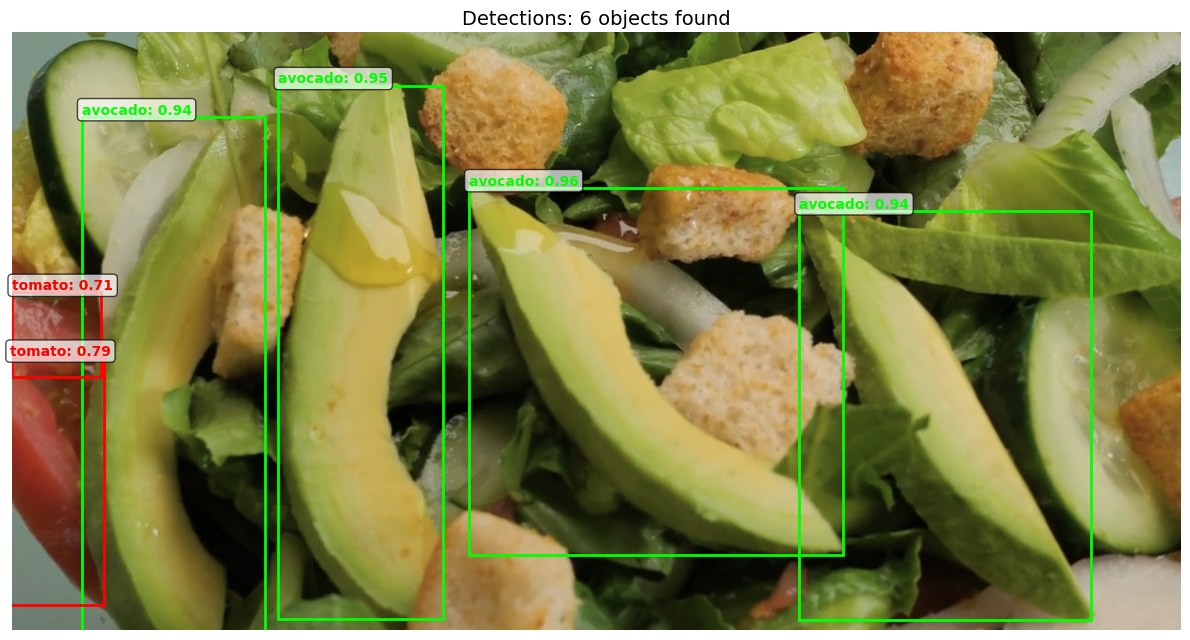

In [36]:
# Visualize image with detections (color-coded by object type)
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(img_rgb)
ax.axis('off')
ax.set_title(f"Detections: {len(all_detections)} objects found", fontsize=14)

# Color map for different object types
label_colors = {
    "avocado": (0, 255, 0),      # Green
    "tomato": (255, 0, 0),       # Red
    "cup": (0, 0, 255),          # Blue
}
default_color = (255, 255, 0)    # Yellow for unknown

# Draw bounding boxes with labels
for det in all_detections:
    label = det.get('label', 'unknown')
    box = det.get('box', [])
    score = det.get('score', 0.0)
    
    if len(box) == 4:
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        
        # Get color for this label
        color_rgb = label_colors.get(label.lower(), default_color)
        color_normalized = tuple(c/255.0 for c in color_rgb)
        
        # Draw rectangle
        rect = Rectangle((x1, y1), width, height, 
                        linewidth=2, edgecolor=color_normalized, 
                        facecolor='none')
        ax.add_patch(rect)
        
        # Add label with object type and score
        label_text = f"{label}: {score:.2f}"
        ax.text(x1, y1 - 10, label_text, 
               color=color_normalized, fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()


## Save Results


In [37]:
import json

# Prepare data to save (with labels)
h, w = img_bgr.shape[:2]
results = {
    "image_path": str(image_path),
    "image_name": image_path.name,
    "width": w,
    "height": h,
    "objects_detected": objects_to_detect,
    "detections": [
        {
            "label": d.get('label', 'unknown'),
            "box": d['box'],
            "score": float(d['score'])
        } 
        for d in all_detections
    ]
}

# Save JSON
output_json = image_path.parent / f"{image_path.stem}_detections.json"
with open(output_json, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved to: {output_json}")

# Save image with detections (color-coded by label)
if len(all_detections) > 0:
    # Create copy of image to draw on
    img_with_detections = img_rgb.copy()
    
    # Color map for different object types
    label_colors_bgr = {
        "avocado": (0, 255, 0),      # Green in BGR
        "tomato": (0, 0, 255),      # Red in BGR
        "cup": (255, 0, 0),         # Blue in BGR
    }
    default_color_bgr = (0, 255, 255)  # Yellow for unknown
    
    # Draw bounding boxes with labels
    for det in all_detections:
        label = det.get('label', 'unknown')
        box = det.get('box', [])
        score = det.get('score', 0.0)
        
        if len(box) == 4:
            x1, y1, x2, y2 = box
            color = label_colors_bgr.get(label.lower(), default_color_bgr)
            
            # Draw rectangle
            cv2.rectangle(img_with_detections, (x1, y1), (x2, y2), color, 2)
            
            # Add label with object type and score
            label_text = f"{label}: {score:.2f}"
            cv2.putText(img_with_detections, label_text, (x1, y1 - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    # Convert RGB to BGR to save with OpenCV
    img_bgr_output = cv2.cvtColor(img_with_detections, cv2.COLOR_RGB2BGR)
    output_image = image_path.parent / f"{image_path.stem}_detections.jpg"
    cv2.imwrite(str(output_image), img_bgr_output)
    print(f"Image with detections saved to: {output_image}")


Results saved to: imgs_demo/salad1_detections.json
Image with detections saved to: imgs_demo/salad1_detections.jpg


## Cleanup Resources


In [26]:
# Close detector
detector.shutdown()
print("Detector closed.")


2025-12-17 17:03:40.281 2594599 INFO     FilterSAM3Detector shutdown
2025-12-17 17:03:40.430 2594599 INFO     FilterSAM3Detector shutdown complete


Detector closed.
